# Strategy 1: Trend-Following (Time-Series Momentum)

**Thesis.** An asset that has been moving strongly in one direction tends
to keep moving in that direction over the near term — the "managed
futures" style signal. Unlike cross-sectional momentum (Strategy 3), this
says nothing about how the asset compares to others; it's a standalone bet
on an asset's own recent direction.

**Signal.** Long if trailing N-period return is positive, short if
negative (`stratlib.strategies.trend_following_signal`).

**What this notebook checks, beyond a single backtest number:**
1. Performance across three genuinely different asset classes (equity,
   crypto, FX) — trend-following is not automatically "an equity
   strategy" or "a crypto strategy."
2. A bootstrap confidence interval on the headline Sharpe ratio.
3. **Regime-conditional performance** — does it actually do best in
   trending regimes, as the name implies? Trending regime split further by
   volatility level, since "trending" alone turns out not to be the whole
   story.
4. **Parameter sensitivity** — is the lookback window a broad plateau or a
   lucky single value?
5. **Walk-forward validation** — is performance consistent across many
   out-of-sample periods, or dominated by a handful of episodes?


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
%matplotlib inline

from stratlib.strategies import trend_following_signal
from stratlib.backtest import single_asset_backtest
from stratlib.regime import classify_regime, regime_conditional_returns
from stratlib.robustness import parameter_sensitivity, walk_forward_validation
from stratlib.stats import sharpe_ci


## 1. Load one representative asset per class

In [2]:
px = pd.read_csv("../data/nyse_prices.csv", parse_dates=["date"])
px = px.pivot(index="date", columns="symbol", values="close").sort_index()
aapl = px["AAPL"].dropna()

btc = pd.read_csv("../data/btc_price.csv", parse_dates=["Date"]).set_index("Date")["Price"].sort_index()
btc = btc[btc > 0]

fx = pd.read_csv("../data/fx_daily.csv", parse_dates=["Date"])
eur = fx[fx["Country"] == "Euro"].set_index("Date")["Exchange rate"].sort_index()
eur = eur[eur.index >= "2010-01-01"]

print(f"AAPL: {aapl.index.min().date()} to {aapl.index.max().date()}")
print(f"BTC:  {btc.index.min().date()} to {btc.index.max().date()}")
print(f"EUR/USD: {eur.index.min().date()} to {eur.index.max().date()}")


AAPL: 2010-01-04 to 2016-12-30
BTC:  2010-07-18 to 2026-04-28
EUR/USD: 2010-01-01 to 2026-08-21


## 2. Backtest across all three asset classes

In [3]:
assets = {
    "AAPL (equity)": (aapl, 252),
    "BTC (crypto)": (btc, 365),
    "EUR/USD (FX)": (eur, 252),
}

cross_asset_results = {}
for name, (price, freq) in assets.items():
    sig = trend_following_signal(price, lookback=90)
    res = single_asset_backtest(price, sig, cost_bps=5.0, freq=freq)
    cross_asset_results[name] = res
    print(f"{name:16} sharpe={res['sharpe']:.3f}  ann_ret={res['ann_return']:.2%}  "
          f"maxdd={res['max_drawdown']:.2%}  trades={res['n_position_changes']}")


AAPL (equity)    sharpe=0.235  ann_ret=5.95%  maxdd=-35.47%  trades=63
BTC (crypto)     sharpe=1.307  ann_ret=115.53%  maxdd=-82.46%  trades=182
EUR/USD (FX)     sharpe=-0.288  ann_ret=-2.28%  maxdd=-36.53%  trades=844


**Sharp asset-class dependence, immediately.** Trend-following is strongly
profitable on BTC, modestly profitable on AAPL, and *loses* money on
EUR/USD. That's not noise — FX majors are actively managed toward
mean-reverting ranges by central banks and have structurally different
dynamics than a young, unregulated asset like BTC that has had genuine
multi-year directional moves.

## 3. How confident should we be in the BTC result specifically?

In [4]:
btc_returns = cross_asset_results["BTC (crypto)"]["returns"]
ci = sharpe_ci(btc_returns, freq=365, n_boot=3000, seed=42)
print(f"BTC trend-following Sharpe: {ci['point_estimate']:.3f}")
print(f"90% bootstrap CI: [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")


BTC trend-following Sharpe: 1.307
90% bootstrap CI: [0.537, 2.454]


Unlike several results elsewhere in this project, this interval does
**not** span zero — the BTC trend-following edge is estimated precisely
enough to call it a real, not-just-noise finding over this sample.

## 4. Regime-conditional performance

In [5]:
regimes = classify_regime(btc, trend_window=60, vol_window=20)
# Use the PREVIOUS period's regime label -- that's what was actually
# knowable at the time the position was taken, avoiding lookahead.
# freq=365 matches BTC's calendar-day (not trading-day) frequency -- a
# mismatch here would silently misstate every annualized number below.
regime_shifted = regimes["regime"].shift(1)
rc = regime_conditional_returns(btc_returns, regime_shifted, freq=365)
rc[["ann_return", "sharpe", "max_drawdown", "n_obs"]].round(3)


,ann_return,sharpe,max_drawdown,n_obs
regime,,,,
Ranging-HighVol,0.412,0.702,-0.710,1289
Ranging-LowVol,0.297,0.424,-0.512,625
Trending-HighVol,0.015,0.021,-0.679,1758
Trending-LowVol,5.134,4.405,-0.703,2091


**The regime split is the most important finding in this notebook.**
Trending-LowVol dominates everything else (Sharpe ~4.4) — the textbook
case where trend-following should work best. But **Trending-HighVol is
nearly flat (Sharpe ~0.02)**, despite also being "trending." Volatility
alone erodes the edge even when the trend classification says the market
is directional: high-vol trending periods likely include sharp
countertrend whipsaws within the broader trend, which a simple
sign-of-trailing-return signal doesn't distinguish from a clean move. The
lesson: "trending" is necessary but not sufficient — volatility context
matters just as much as trend classification.

## 5. Parameter sensitivity: is 90 days a lucky number?

In [6]:
bt = partial(single_asset_backtest, cost_bps=5.0, freq=365)
grid = {"lookback": [20, 40, 60, 90, 120, 180, 252]}
sens = parameter_sensitivity(btc, trend_following_signal, bt, grid, metric="sharpe")
sens


,lookback,sharpe
0,20,1.346074
1,40,1.800213
2,60,1.545595
3,90,1.306677
4,120,0.902415
5,180,0.874347
6,252,1.420484


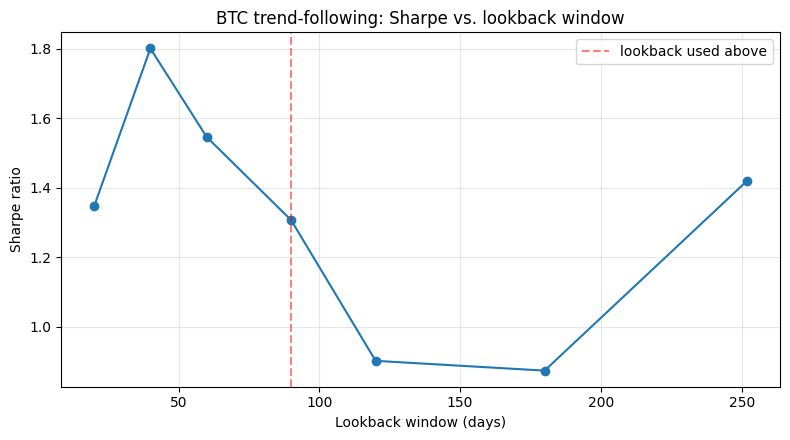

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sens["lookback"], sens["sharpe"], marker="o")
ax.axvline(90, color="red", ls="--", alpha=0.5, label="lookback used above")
ax.set_xlabel("Lookback window (days)")
ax.set_ylabel("Sharpe ratio")
ax.set_title("BTC trend-following: Sharpe vs. lookback window")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("trend_following_sensitivity.png", dpi=110)
plt.show()


Every lookback from 20 to 252 days produces a **positive** Sharpe — this
is a broad plateau, not a knife-edge result that only works at exactly 90
days. That's the right kind of robustness check: it doesn't prove the
strategy is "correct," but it does rule out the specific failure mode of
having accidentally grid-searched into a lucky single parameter.

## 6. Walk-forward validation: consistent, or a few big episodes?

In [8]:
wf = walk_forward_validation(
    btc, trend_following_signal, bt, params={"lookback": 90},
    train_window=180, test_window=180,
)
print(f"{len(wf)} non-overlapping 180-day out-of-sample folds")
wf[["fold_start", "fold_end", "sharpe", "ann_return"]].round(3)


31 non-overlapping 180-day out-of-sample folds


/tmp/ipykernel_687/129655133.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  wf[["fold_start", "fold_end", "sharpe", "ann_return"]].round(3)


,fold_start,fold_end,sharpe,ann_return
0,2011-01-14,2011-07-12,116.859,197.520
1,2011-07-13,2012-01-08,-0.374,-0.483
2,2012-01-09,2012-07-06,-0.299,-0.171
3,2012-07-07,2013-01-02,1.455,0.941
4,2013-01-03,2013-07-01,16.397,18.371
5,2013-07-02,2013-12-28,3.821,4.619
6,2013-12-29,2014-06-26,-0.638,-0.473
7,2014-06-27,2014-12-23,-0.121,-0.058
8,2014-12-24,2015-06-21,0.290,0.180
9,2015-06-22,2015-12-18,-0.120,-0.060


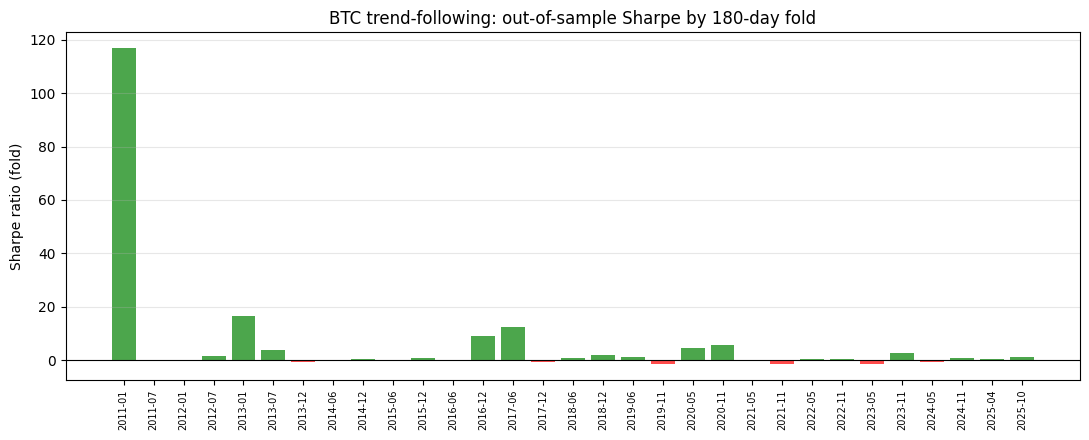

Fraction of folds with positive Sharpe: 61.3%


In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ["green" if s > 0 else "red" for s in wf["sharpe"]]
ax.bar(range(len(wf)), wf["sharpe"], color=colors, alpha=0.7)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(len(wf)))
ax.set_xticklabels([d.strftime("%Y-%m") for d in wf["fold_start"]], rotation=90, fontsize=7)
ax.set_ylabel("Sharpe ratio (fold)")
ax.set_title("BTC trend-following: out-of-sample Sharpe by 180-day fold")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("trend_following_walkforward.png", dpi=110)
plt.show()

win_rate = (wf["sharpe"] > 0).mean()
print(f"Fraction of folds with positive Sharpe: {win_rate:.1%}")


**This is the honest caveat the aggregate Sharpe hides.** A little over
half of the individual 180-day folds are profitable; the rest are flat or
losing. The strongest folds (early 2011, early/mid 2013, mid-late 2017)
coincide with BTC's most extreme historical bull runs — meaning a real
share of the aggregate edge is concentrated in a small number of episodes,
not spread evenly across time. The first fold's numbers (Sharpe >100) are
a known artifact of BTC's early history, when it moved from fractions of
a cent to real dollar values — a genuine feature of the data, not a bug,
but not representative of what a live trading period looks like either.


## 7. Discussion: risks and when to use this strategy

**When it's likely to work:** assets with genuine, sustained directional
regimes and moderate-to-low realized volatility during those trends —
this describes BTC in this sample far better than it describes a managed
FX major.

**When it's likely to fail:** range-bound or actively mean-reverted
assets (like major FX pairs, which central banks lean against), and
"trending but choppy" regimes where the trend classification is technically
satisfied but whipsaw erodes the edge.

**Risks and factors:**
- **Whipsaw / false-trend risk** — the Trending-HighVol regime result
  shows this directly: the signal can be "right" about direction and
  still not make money if volatility is high enough.
- **Concentration in a few episodes** — the walk-forward result shows
  performance isn't evenly distributed across time; a large share of
  cumulative return can come from a small number of strong trending
  windows.
- **Parameter robustness is reassuring but not proof** — a broad
  sensitivity plateau rules out one specific overfitting failure mode
  (lucky single parameter), not all of them.
- **Capacity and crowding** — time-series trend-following is one of the
  most widely traded systematic strategies (the entire CTA/managed
  futures industry runs variants of it); on liquid, widely-followed
  assets, edges can compress over time as more capital chases the same
  signal.
- **Transaction costs matter on choppier assets** — EUR/USD's negative
  result here is partly a real behavioral difference and partly a high
  number of position changes relative to the size of moves being
  captured; a slower version of the signal might behave differently on
  FX specifically, which is exactly the kind of asset-specific tuning a
  systematic desk would do rather than assuming one lookback fits all
  markets.
